# Quantile Regression

In [2]:
library(quantreg)

In [3]:
data(engel)
head(engel)

,income,foodexp
,<dbl>,<dbl>
1,420.1577,255.8394
2,541.4117,310.9587
3,901.1575,485.6800
4,639.0802,402.9974
5,750.8756,495.5608
6,945.7989,633.7978


In [4]:
summary(engel)

     income          foodexp      
 Min.   : 377.1   Min.   : 242.3  
 1st Qu.: 638.9   1st Qu.: 429.7  
 Median : 884.0   Median : 582.5  
 Mean   : 982.5   Mean   : 624.2  
 3rd Qu.:1164.0   3rd Qu.: 743.9  
 Max.   :4957.8   Max.   :2032.7  

In [8]:
OLS = lm(foodexp~income, data=engel)
summary(OLS)


Call:
lm(formula = foodexp ~ income, data = engel)

Residuals:
    Min      1Q  Median      3Q     Max 
-725.70  -60.24   -4.32   53.41  515.77 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 147.47539   15.95708   9.242   <2e-16 ***
income        0.48518    0.01437  33.772   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 114.1 on 233 degrees of freedom
Multiple R-squared:  0.8304,	Adjusted R-squared:  0.8296 
F-statistic:  1141 on 1 and 233 DF,  p-value: < 2.2e-16


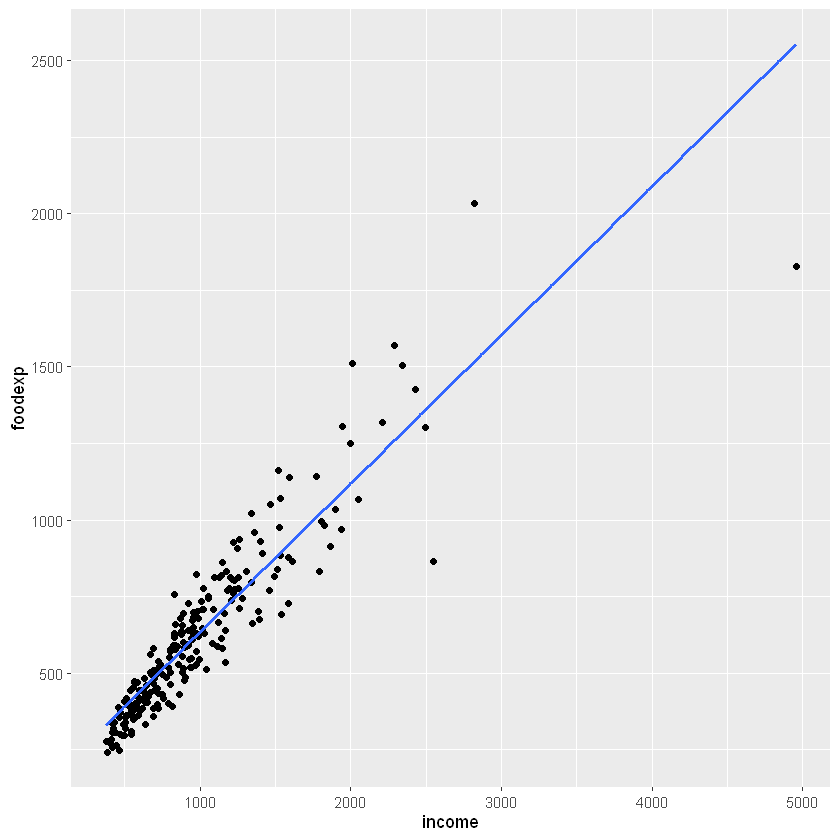

In [10]:
library(ggplot2)
ggplot(engel, aes(income, foodexp))+geom_point()+geom_smooth(method="lm", formula=y~x, se=F)

In [11]:
med_reg = rq(foodexp~income, data=engel, tau=0.5)
summary(med_reg)


Call: rq(formula = foodexp ~ income, tau = 0.5, data = engel)

tau: [1] 0.5

Coefficients:
            coefficients lower bd  upper bd 
(Intercept)  81.48225     53.25915 114.01156
income        0.56018      0.48702   0.60199

In [15]:
reg_10 = rq(foodexp~income, data=engel, tau=0.1)
reg_90 = rq(foodexp~income, data=engel, tau=0.9)

summary(reg_10)
summary(reg_90)


Call: rq(formula = foodexp ~ income, tau = 0.1, data = engel)

tau: [1] 0.1

Coefficients:
            coefficients lower bd  upper bd 
(Intercept) 110.14157     79.88753 146.18875
income        0.40177      0.34210   0.45079


Call: rq(formula = foodexp ~ income, tau = 0.9, data = engel)

tau: [1] 0.9

Coefficients:
            coefficients lower bd  upper bd 
(Intercept)  67.35087     37.11802 103.17399
income        0.68630      0.64937   0.74223

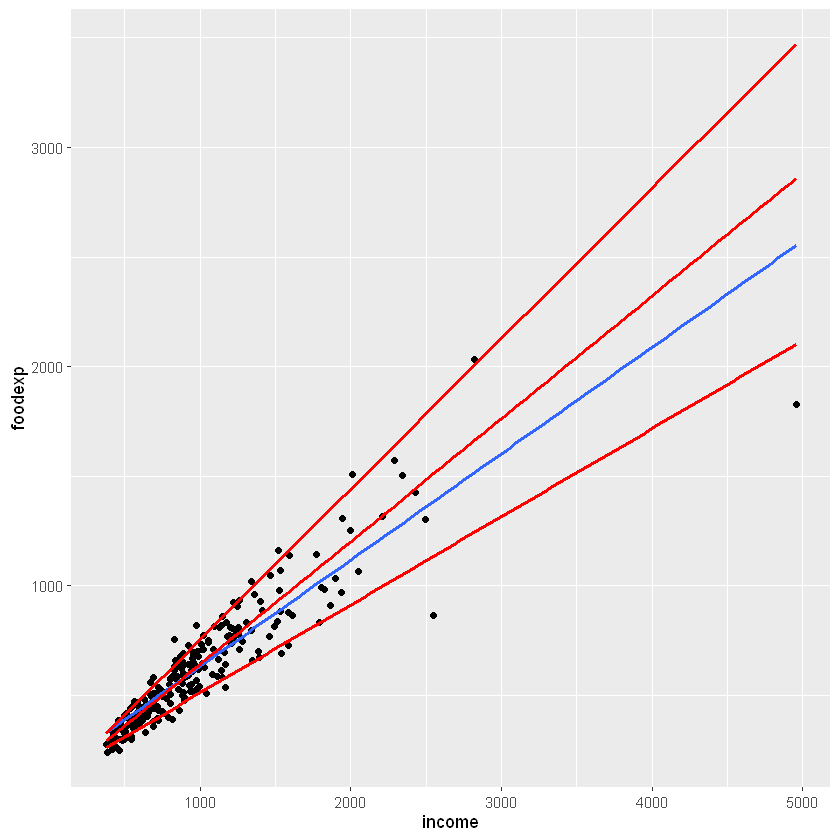

In [22]:
ggplot(engel, aes(income, foodexp))+geom_point()+
    geom_smooth(method="lm", formula=y~x, se=F) +
    geom_quantile(quantiles = c(0.1,0.5,0.9), formula=y~x, color="red", linewidth=1)

In [23]:
anova(reg_10,reg_90)

Quantile Regression Analysis of Deviance Table

Model: foodexp ~ income
Joint Test of Equality of Slopes: tau in {  0.1 0.9  }

  Df Resid Df F value    Pr(>F)    
1  1      469  37.191 2.241e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

The null hypothesis is that the slopes of the 10th and 90th quantile regressions are not different. Since the p-value is 0+, we reject the null hypothesis and conclude that there is significant evidence to say that these two slopes are not the same!